In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb 

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Pour el clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('/Users/bigkems/Desktop/Projets Perso/Formation AI-engineer/Projet Fitness_market/data/clean_gym_data.csv')

In [4]:
features = df[[
    "population_total",
    "urban_population_percentage",
    "gdp_per_capita_usd",
    "number_of_gyms"
]]

features = features.dropna()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

On transforme les donnees brutes en donnees standardise. On veut pas que le GDP ecrase tout comme les valeurs se comptent en B, tandis que d'autre sont de l'ordre 10^-1

In [11]:
# Elbow Method

from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

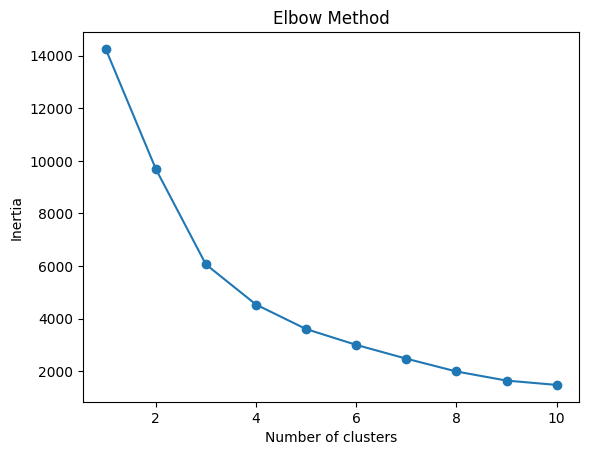

In [12]:
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

On choisit une valeur de k ou on a un genre de coude: On prend le 4

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [9]:
df_clusters = features.copy()
df_clusters["cluster"] = clusters

In [10]:
df_clusters.groupby("cluster").mean()

,population_total,urban_population_percentage,gdp_per_capita_usd,number_of_gyms
cluster,,,,
0,3.862181e+07,0.329921,1943.956187,773.896104
1,2.792533e+07,0.681733,9715.930334,1614.486914
2,1.021066e+09,0.539232,20886.593475,27489.311688
3,2.502286e+07,0.846619,52576.123621,2374.996933
